# Данные
Синтетический датасет e-commerce с пользовательскими сессиями просмотра товаров. Каждая сессия — это последовательность ID товаров, которые один пользователь просмотрел по порядку. Каждая сессия содержит не менее 3 товаров.

Данные хранятся в формате JSON Lines (sessions.jsonl): каждая строка — это JSON-массив, представляющий одну сессию. Элементы массива — целочисленные ID товаров

Товары в сессии упорядочены по времени просмотра: первый элемент — самое раннее взаимодействие, последний — самое позднее. 

## Часть 0 Импорт данных

In [11]:
import json
sessions = [] # sessions — список списков целых чисел
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip() # убирает пробелы и переносы строк по краям строки
        if line:
            sessions.append(json.loads(line)) # было ['[1, 2]', '[1, 2, 3]'...] стало [[1, 2], [1, 2, 3]...]

## Часть 1 Анализ данных



In [12]:
print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]


In [20]:
all_items = [i for l in sessions for i in l]
unique = set(all_items)
print("Число уникальных товаров:", len(unique))

Число уникальных товаров: 400


#### Распределение длин сессий

In [55]:
lengths = {}

for i in sessions:
    l = len(i)
    if l in lengths:
        lengths[l] += 1
    else:
        lengths[l] = 1

print(lengths)


{17: 65, 8: 160, 7: 186, 11: 108, 5: 214, 19: 49, 9: 125, 4: 246, 10: 135, 14: 86, 6: 154, 20: 410, 18: 62, 3: 249, 16: 60, 15: 72, 12: 115, 13: 69}


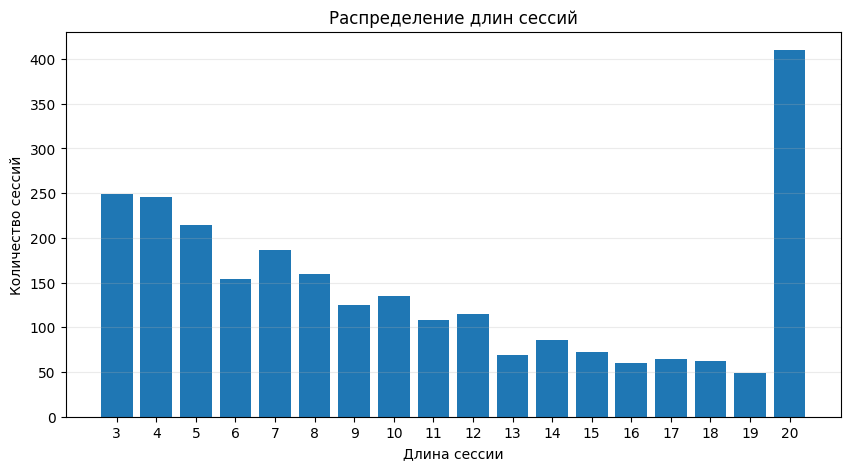

In [54]:
import matplotlib.pyplot as plt

items = sorted(lengths.items())

x = [i[0] for i in items]
y = [i[1] for i in items]

plt.figure(figsize=(10, 5))
plt.bar(x, y)

plt.xlabel("Длина сессии")
plt.ylabel("Количество сессий")
plt.title("Распределение длин сессий")

plt.xticks(x)  # для значений на оси x
plt.grid(True, axis='y', linestyle='-', alpha=0.25)

plt.show()

Большинство сессий имеют длину примерно 3–12 товаров, что говорит о том, что пользователи совершают короткие последовательности взаимодействий.

В распределении длин сессий наблюдается аномально высокий пик на значении 20.
Это может указывать на искусственное ограничение длины сессий в датасете, где значения >= 20 объединены в одну категорию.

#### Частоты товаров 

In [181]:
q = {} # {товар: сколько раз встречался}

for s in sessions:
    for i in s:
        if i in q:
            q[i] += 1
        else:
            q[i] = 1

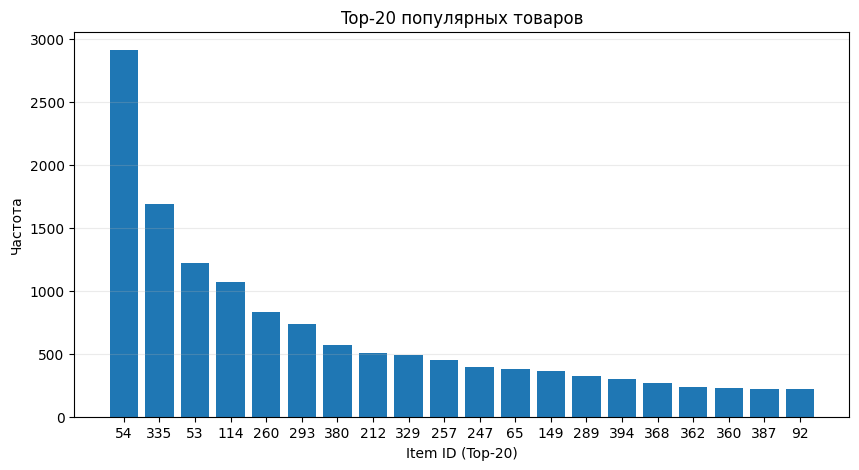

In [224]:
import matplotlib.pyplot as plt

top_items = sorted(q.items(), key=lambda x: x[1], reverse=True)[:20]

labels = [i[0] for i in top_items]
values = [i[1] for i in top_items]

plt.figure(figsize=(10, 5))
plt.bar(range(len(values)), values)

plt.xticks(range(len(values)), labels)
plt.xlabel("Item ID (Top-20)")
plt.ylabel("Частота")
plt.title("Top-20 популярных товаров")
plt.grid(True, axis='y', linestyle='-', alpha=0.25)

plt.show()

Товар 54 является наиболее популярным и встречается значительно чаще остальных (почти 3000 раз), сильно опережая следующий по частоте товар (около 1600).Такой разрыв может указывать на сильную популярность отдельного товара либо на особенности создания датасета. Также наблюдается длинный хвост - большинство товаров встречаются редко, это может усложнить предсказание редких товаров

#### Сводные показатели

In [110]:
length_list = [len(s) for s in sessions]

print("Средняя длина:", sum(length_list) / len(length_list))
print("Медиана:", sorted(length_list)[len(length_list)//2])
print("Мин:", min(length_list))
print("Макс:", max(length_list))

Средняя длина: 10.465107212475633
Медиана: 9
Мин: 3
Макс: 20


Средняя длина сессии (10.47) превышает медиану (9), что указывает на правостороннюю асимметрию распределения: относительно длинные сессии 
смещают среднее вверх.


Максимальная длина равна 20 и совпадает с ранее наблюдаемым пиком на этом значении, что может свидетельствовать о наличии ограничения длины сессий, а не о единичных выбросах.

In [111]:
repeats = sum(len(s) - len(set(s)) for s in sessions)
print("Повторы внутри сессий:", repeats)

Повторы внутри сессий: 3780


В данных присутствуют повторные взаимодействия с одними и теми же товарами внутри одной сессии (суммарно 3780 повторов). Это означает, что пользователь может несколько раз возвращаться к ранее просмотренным товарам в рамках одной сессии.
Данный факт важно учитывать, так как последовательность взаимодействий не всегда является строго уникальной, и повторные переходы могут влиять на оценку вероятностей переходов между товарами

In [122]:
total = sum(q.values())

top5 = sum(v for _, v in sorted(q.items(), key=lambda x: x[1], reverse=True)[:5])

print("Доля топ-5 товаров:", top5 / total)

Доля топ-5 товаров: 0.28789628581008087


Топ-5 товаров составляют около 28% всех взаимодействий - пользователи часто смотрят одни и те же популярные товары. Это значит что простая модель, которая рекомендует только самые популярные товары, возможно, тоже будет работать неплохо

In [226]:
rare = sum(1 for v in q.values() if v == 1)
print("Товаров, встретившихся 1 раз:", rare)

Товаров, встретившихся 1 раз: 0


Товаров, встречающихся ровно один раз, в данных нет. Это означает, что каждый объект присутствует минимум в нескольких взаимодействиях.
Такое распределение упрощает задачу, поскольку отсутствуют объекты без истории

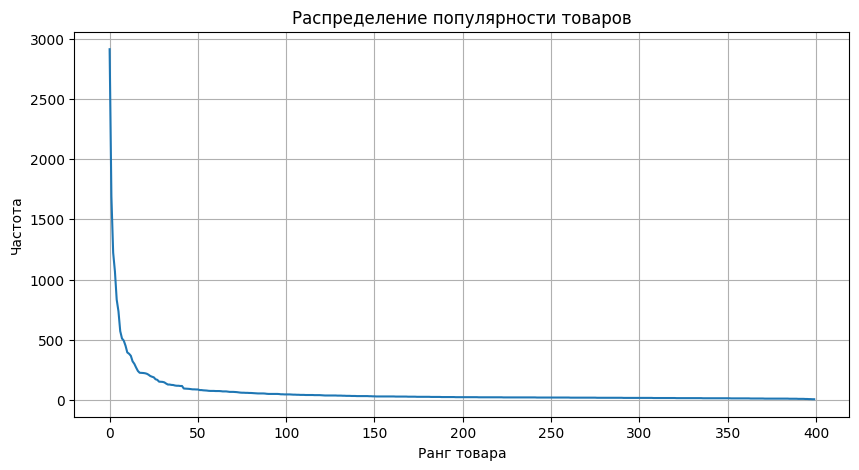

In [126]:
val = sorted(q.values(), reverse=True)

plt.figure(figsize=(10,5))
plt.plot(val)
plt.title("Распределение популярности товаров")
plt.xlabel("Ранг товара")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

Небольшое количество товаров встречается значительно чаще остальных, тогда как основная масса объектов имеет существенно меньшую частоту.

Под рангом товара понимается его позиция в списке, отсортированном по убыванию частоты. Таким образом, наиболее популярный товар имеет ранг 0, а наименее популярные — наибольшие значения ранга (в данном случае 400).

## Часть 2 Разбиение train / test


    Для каждой сессии:
      - все товары кроме последнего становятся
        обучающей сессией
      - последний товар становится тестовой целью

    Возвращаемые списки выровнены по индексу:
    test_targets[i] — товар, который нужно
    предсказать по train_sessions[i] как истории.

    Parameters
    ----------
    sessions : list of lists of ints
        Каждый вложенный список — одна сессия ID
        товаров, упорядоченная по времени.
        Все сессии содержат не менее 3 товаров.

    Returns
    -------
    train_sessions : list of lists of ints
        Сессии для обучения (исходные без последнего товара).
    test_targets : list of ints
        Следующий товар для предсказания по каждой сессии.

In [163]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets

Почему случайное разбиение для таких данных не подходит?

Случайное разбиение данных для данной задачи не подойдет, потому что оно нарушает временную структуру взаимодействий.

Если случайно выбрать элементы сессии для теста, то в обучающую выборку могут попасть товары, которые следуют позже по времени. В таком случае модель фактически получает информацию о будущих действиях пользователя при обучении.

Это приводит к утечке данных: модель обучается на информации, которая в реальном сценарии предсказания ей недоступна. В результате оценка качества не отражает реальную способность модели предсказывать следующий товар.

Поэтому нужный подход — сохранять порядок взаимодействий и использовать для теста последний элемент каждой сессии.

## Часть 3 Граф переходов

In [143]:
graf = {}

for s in train_sessions:
    for i in range(len(s) - 1):
        current = s[i]
        next_item = s[i + 1]
        
        if current not in graf:
            graf[current] = {}
        
        if next_item not in graf[current]:
            graf[current][next_item] = 0
            
        graf[current][next_item] += 1

На обучающих данных построен граф переходов между товарами. Для каждой пары соседних товаров (i, j) внутри сессий подсчитывается
число переходов из i в j.

Результатом является словарь, где для каждого товара хранится распределение частот переходов к следующим товарам.

Пример:

#### [1, 2, 3]
#### [1, 2]
       
Итог: graf = {
    1: {2: 2},
    2: {3: 1}
    } 

Что означает: из 1 пользователи переходили в 2 два раза, из 2 переходили в 3 только один раз, благодаря чему можно утверждать, если пользователь находится на товаре 1, то вероятнее всего он перейдет дальще в 2 

#### Оценка вероятностей переходов 

P(j | i) — вероятность того, что сразу после i будет просмотрен j. 
Для каждого товара i оценивается вероятность перехода к товару j:

$$
P(j \mid i) = \frac{count(i \to j)}{\sum_k count(i \to k)}
$$

где:

числитель — число переходов из товара i в товар j  
знаменатель — суммарное число всех исходящих переходов из товара i

In [227]:
probs = {} 

for i in graf:
    total = sum(graf[i].values())
    probs[i] = {} 
    for j in graf[i]:
        probs[i][j] = graf[i][j] / total

Граф переходов строится только на обучающих (train) данных. Поэтому возможна ситуация, когда некоторый товар не встречается в train-сессиях и, соответственно, отсутствует в словаре вероятностей probs.

Если пользователь сейчас находится на таком товаре, мы не можем оценить, какие товары обычно просматриваются после него, так как у модели нет статистики переходов.

В этом случае можно, например, вместо предсказаний по графу возвращать самые популярные товары в датасете, чтобы не возвращать пустой список

In [159]:
print(f"Уникальных товаров в датасете: {len(unique)}")
print(f"Товаров в графе переходов: {len(probs)}")

Уникальных товаров в датасете: 400
Товаров в графе переходов: 400


В данном датасете все товары присутствуют в обучающих данных, поэтому такая ситуация не возникает

Также стоит рассмотреть товары с малым числом переходов, так как вероятности для них ненадежные (мало данных для статистики) 

In [166]:
low_count = {}
for i in graf:
    total = sum(graf[i].values())
    if total < 5:
        low_count[i] = total
print(f"Товаров с менее чем 5 переходами: {len(low_count)}")

Товаров с менее чем 5 переходами: 3


In [165]:
print(f"Товары с малым числом переходов: {low_count}")

Товары с малым числом переходов: {326: 4, 184: 3, 374: 3}


В датасете присутствуют товары с малым числом переходов: 326, 184, 374. Оценки вероятностей переходов для таких товаров могут быть нестабильными из-за недостатка наблюдений

Специальной работы с ними не буду реализовывать, поскольку:
1. таких товаров только 3
2. при малом числе переходов модель все равно возвращает разумные рекомендации на основе имеющихся данных
3. датасет является синтетическим, поэтому нет случаев, когда переходов 1 или 2

В более реалистичных условиях для повышения устойчивости модели можно рекомендовать наиболее популярные товары, также в ходе изучения задачи я узнала о методе сглаживания вероятностей. Это способ, когда вероятности переходов делают более устойчивыми, для редких случаев. Если переход между товарами встретился всего пару раз, модель может переоценить его значимость. Сглаживание добавляет поправку ко всем переходам, чтобы снизить влияние случайных наблюдений и избежать нулевых вероятностей. Интуитивно это означает, что модель не полностью доверяет редким событиям и учитывает, что данные могут быть ограниченными

#### Используют формулу:

$$
P(j \mid i) = \frac{count(i \to j) + \alpha}{total + \alpha \cdot N}
$$

где:
- count(i -> j) — число переходов из товара i в товар j
- total — общее число переходов из товара i
- N — число всех товаров
- alpha — параметр сглаживания

#### Пример

Пусть из товара A наблюдался только один переход, всего товаров 3:

- A → B: 1 раз

Без сглаживания:

$$
P(B \mid A) = 1 / 1 = 1.0
$$

Со сглаживанием при alpha = 1 (обычно берут столько), N = 3 (по условию примера):

- A → B: ( 1 + 1 = 2 )  
- A → C: ( 0 + 1 = 1 )  
- A → D: ( 0 + 1 = 1 )

Тогда:

$$
P(B \mid A) = 2 / 4 = 0.5
$$

Сглаживание уменьшает переоценку редких переходов и позволяет избежать нулевых вероятностей.

## Часть 4 Рекомендательная модель

     По последнему товару в сессии возвращайте топ-10 кандидатов, отранжированных по вероятности перехода. 

In [228]:
def model(last_item, # последний элемент в сессии
          probs, # словарь вероятностей переходов
          top_popular, # список популярных товаров
          k = 10 # кол-во элементов, которые хотим вернуть
         ):
    
    # базовые рекомендации
    if last_item in probs: 
        next_items = probs[last_item]
        sorted_items = sorted(next_items.items(), key=lambda x: x[1], reverse=True)
        recs = [item for item, _ in sorted_items if item != last_item]
    else:
        recs = []

    # если рекомендаций меньше k — добираем популярными
    for item in top_popular:
        if len(recs) == k:
            break
        if item not in recs and item != last_item:
            recs.append(item)

    return recs

In [229]:
top_popular = [item for item, _ in sorted(q.items(), key=lambda x: x[1], reverse=True)] # cписок всех товаров отсортированных по частоте (от большего)


rec = [] # массив для хранения рекомендаций для каждой сессии

for session in train_sessions:
    last_item = session[-1]
    recs = model(last_item, probs, top_popular, k = 10)
    rec.append(recs) # массив из массивов на каждую сессию

In [213]:
print(f"Пример рекомендаций: {rec[0]}")

Пример рекомендаций: [92, 149, 54, 287, 7, 212, 12, 260, 380, 335]


В результате для каждой сессии формируется список из 10 рекомендаций.

Пример рекомендаций для первой сессии:
[92, 149, 54, 287, 7, 212, 12, 260, 380, 335]

Рекомендации упорядочены по убыванию вероятности перехода: сначала идут наиболее вероятные товары, затем — менее вероятные, а в конце (при необходимости) добавляются популярные товары.

## Часть 5 Оценка качества

    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.

In [220]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    
    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

In [223]:
score = hit_at_k(rec, test_targets)
print(f"Hit@10 модели: {score:.4f}")

top10_popular = top_popular[:10]
bl_recs = [top10_popular] * len(test_targets)
bl_score = hit_at_k(bl_recs, test_targets)
print(f"Hit@10 бейзлайна: {bl_score:.4f}")

Hit@10 модели: 0.5142
Hit@10 бейзлайна: 0.3840


### Оценка модели
Модель оценивалась с помощью метрики Hit@10 — она показывает как часто правильный следующий товар попадает в топ-10 рекомендаций.

Результаты:
- Hit@10 модели (граф переходов): 0.5142
- Hit@10 бейзлайна (топ-10 популярных): 0.3840

Модель обходит бейзлайн на 13% — учет переходов между товарами действительно помогает предсказывать следующий товар лучше чем просто популярность.

Результат не идеальный (51%), что объясняется ограничениями модели: она смотрит только на последний товар в сессии, или также не учитывает всю историю просмотров, что влияет на результат.
